In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display

release_name = "analysis_release_v1_20261005T194400349609Z"
current_dir = Path.cwd().resolve()

ROOT = next(
    (
        folder
        for folder in [current_dir, *current_dir.parents]
        if (folder / "data/processed" / release_name).is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Không tìm thấy release trong project.")

RELEASE_DIR = ROOT / "data" / "processed" / release_name

countries = pd.read_csv(
    RELEASE_DIR / "country_prizes.csv",
    encoding="utf-8-sig",
    dtype={"tournament_id": "string", "country_code": "string"},
)
country_audit = pd.read_csv(
    RELEASE_DIR / "country_audit.csv",
    encoding="utf-8-sig",
    dtype={"tournament_id": "string"},
)

assert country_audit["tournament_id"].is_unique
assert not countries.duplicated(
    ["tournament_id", "country_code"]
).any()

print("Số dòng giải–quốc gia:", len(countries))
print("Số giải được kiểm tra:", len(country_audit))
display(country_audit["status"].value_counts().to_frame("Số giải"))

Số dòng giải–quốc gia: 57597
Số giải được kiểm tra: 14082


,Số giải
status,
reconciled,12548
total_mismatch,1076
unavailable,458


#### Tính độ phủ theo game

In [2]:
expected_statuses = {"reconciled", "total_mismatch", "unavailable"}
assert country_audit["status"].isin(expected_statuses).all()

audit = country_audit.copy()
audit["accepted"] = audit["status"].eq("reconciled")

audit["accepted_pool_cents"] = audit["pool_cents"].where(
    audit["accepted"], 0
)

coverage = audit.groupby("game_family").agg(
    so_giai_kiem_tra=("tournament_id", "size"),
    so_giai_doi_chieu_dat=("accepted", "sum"),
    tong_quy_thuong_cents=("pool_cents", "sum"),
    quy_thuong_duoc_dai_dien_cents=("accepted_pool_cents", "sum"),
)

coverage["do_phu_so_giai_pct"] = (
    coverage["so_giai_doi_chieu_dat"]
    / coverage["so_giai_kiem_tra"] * 100
)
coverage["do_phu_quy_thuong_pct"] = (
    coverage["quy_thuong_duoc_dai_dien_cents"]
    / coverage["tong_quy_thuong_cents"] * 100
)

display(coverage[[
    "so_giai_kiem_tra",
    "so_giai_doi_chieu_dat",
    "do_phu_so_giai_pct",
    "do_phu_quy_thuong_pct",
]].round(2))

,so_giai_kiem_tra,so_giai_doi_chieu_dat,do_phu_so_giai_pct,do_phu_quy_thuong_pct
game_family,,,,
Counter-Strike,7938,7516,94.68,97.65
Dota 2,1977,1633,82.60,99.17
League of Legends,2836,2149,75.78,92.86
Valorant,1331,1250,93.91,98.17


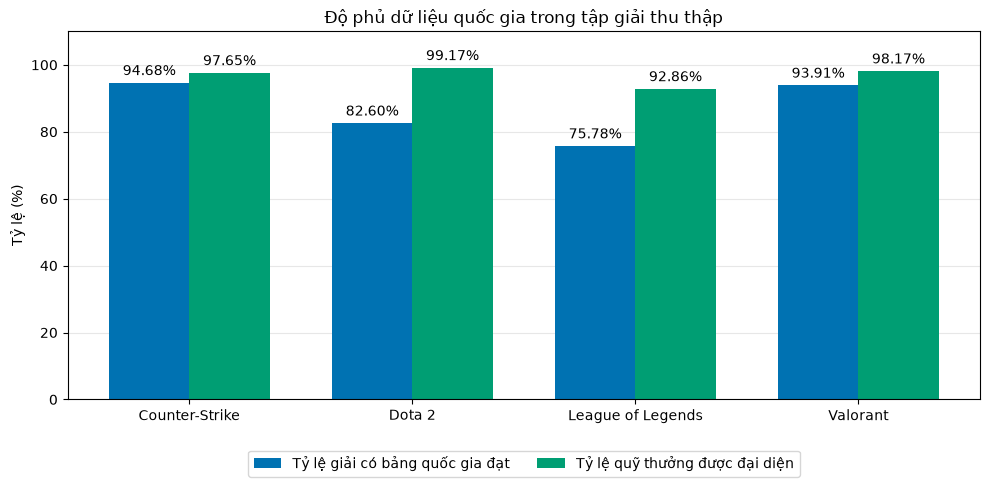

In [3]:
import numpy as np
import matplotlib.pyplot as plt

games = ["Counter-Strike", "Dota 2", "League of Legends", "Valorant"]
chart = coverage.reindex(games)

x = np.arange(len(games))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

bars_count = ax.bar(
    x - width / 2,
    chart["do_phu_so_giai_pct"],
    width,
    label="Tỷ lệ giải có bảng quốc gia đạt",
    color="#0072B2",
)
bars_money = ax.bar(
    x + width / 2,
    chart["do_phu_quy_thuong_pct"],
    width,
    label="Tỷ lệ quỹ thưởng được đại diện",
    color="#009E73",
)

ax.bar_label(bars_count, fmt="%.2f%%", padding=3)
ax.bar_label(bars_money, fmt="%.2f%%", padding=3)

ax.set_xticks(x, games)
ax.set_ylim(0, 110)
ax.set_ylabel("Tỷ lệ (%)")
ax.set_title("Độ phủ dữ liệu quốc gia trong tập giải thu thập")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

#### Tổng hợp theo game–quốc gia

In [6]:
countries = pd.read_csv(
    RELEASE_DIR / "country_prizes.csv",
    encoding="utf-8-sig",
    dtype={
        "tournament_id": "string",
        "country_code": "string",
    },
    keep_default_na=False,
)

In [7]:
countries["prize_cents"] = pd.to_numeric(
    countries["prize_cents"], errors="raise"
)

assert countries["country_code"].notna().all()
assert countries["prize_cents"].notna().all()
assert countries["prize_cents"].ge(0).all()

country_totals = (
    countries.groupby(
        ["game_family", "country_code"], as_index=False
    )
    .agg(
        country_name=("country_name", "first"),
        prize_cents=("prize_cents", "sum"),
    )
)

country_totals["prize_usd"] = country_totals["prize_cents"] / 100

country_totals["share_pct"] = (
    country_totals["prize_cents"]
    / country_totals.groupby("game_family")["prize_cents"].transform("sum")
    * 100
)

top10_country = (
    country_totals.sort_values(
        ["game_family", "prize_cents"],
        ascending=[True, False],
    )
    .groupby("game_family")
    .head(10)
)

display(top10_country[[
    "game_family", "country_name", "prize_usd", "share_pct"
]].round(2))

,game_family,country_name,prize_usd,share_pct
28,Counter-Strike,Denmark,25953321.34,12.74
96,Counter-Strike,Russian Federation,22538010.82,11.07
15,Counter-Strike,Brazil,15046005.04,7.39
109,Counter-Strike,United States,14848961.03,7.29
98,Counter-Strike,Sweden,14114396.90,6.93
37,Counter-Strike,France,12826425.68,6.30
89,Counter-Strike,Poland,9808906.95,4.82
108,Counter-Strike,Ukraine,8911412.81,4.38
18,Counter-Strike,Canada,6151644.40,3.02
27,Counter-Strike,Germany,5167962.45,2.54


#### Vẽ top 10 quốc gia của từng game

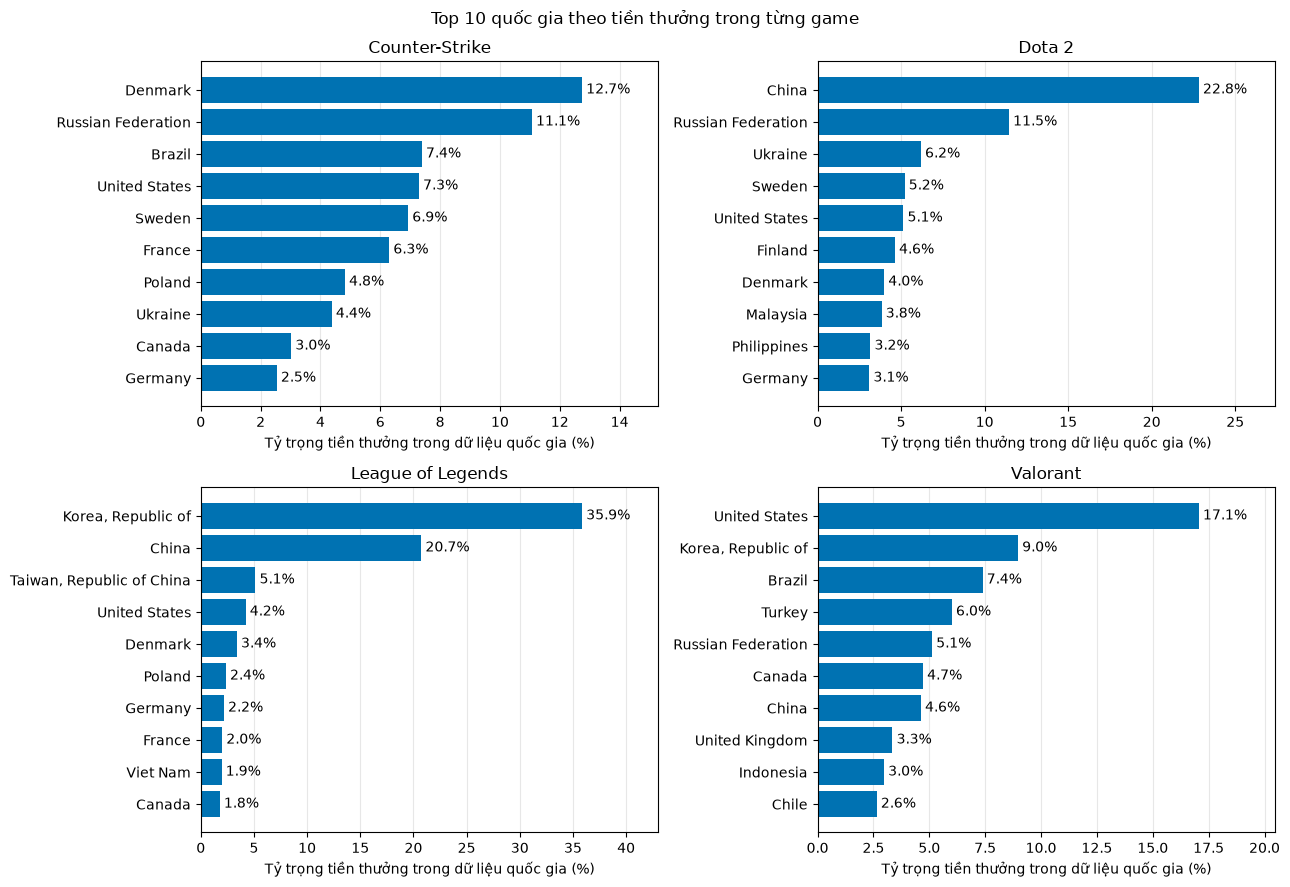

In [8]:
import matplotlib.pyplot as plt

games = ["Counter-Strike", "Dota 2", "League of Legends", "Valorant"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, game in zip(axes.flat, games):
    group = top10_country.loc[
        top10_country["game_family"].eq(game)
    ].sort_values("share_pct")

    bars = ax.barh(
        group["country_name"],
        group["share_pct"],
        color="#0072B2",
    )

    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_title(game)
    ax.set_xlabel("Tỷ trọng tiền thưởng trong dữ liệu quốc gia (%)")
    ax.set_ylabel("")
    ax.margins(x=0.20)
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle("Top 10 quốc gia theo tiền thưởng trong từng game")
fig.tight_layout()
plt.show()

#### Tính mức tập trung vào top 5 quốc gia

In [9]:
concentration_country = (
    country_totals.groupby("game_family")
    .agg(
        so_quoc_gia=("country_code", "size"),
        top5_share_pct=("share_pct", lambda s: s.nlargest(5).sum()),
    )
)

display(concentration_country.round(2))

,so_quoc_gia,top5_share_pct
game_family,,
Counter-Strike,116,45.42
Dota 2,94,50.79
League of Legends,104,69.32
Valorant,101,44.54


#### Tính tỷ trọng tiền thưởng theo quốc gia và năm

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

country_time = countries.copy()

country_time["year"] = pd.to_numeric(
    country_time["year"], errors="raise"
).astype(int)

country_time["prize_cents"] = pd.to_numeric(
    country_time["prize_cents"], errors="raise"
)

# Tổng tiền thưởng của từng quốc gia trong từng năm, từng game
country_year = (
    country_time
    .groupby(
        ["game_family", "year", "country_code"],
        as_index=False
    )
    .agg(
        country_name=("country_name", "first"),
        prize_cents=("prize_cents", "sum"),
    )
)

# Mẫu số: tổng tiền thưởng quốc gia của cùng game và cùng năm
year_total = (
    country_year
    .groupby(["game_family", "year"])["prize_cents"]
    .transform("sum")
)

country_year["share_pct"] = (
    country_year["prize_cents"]
    / year_total.where(year_total.gt(0))
    * 100
)

# Chọn cố định top 3 quốc gia theo tổng tiền thưởng toàn giai đoạn
leaders = (
    country_year
    .groupby(
        ["game_family", "country_code"],
        as_index=False
    )
    .agg(
        country_name=("country_name", "first"),
        prize_cents=("prize_cents", "sum"),
    )
    .sort_values(
        ["game_family", "prize_cents", "country_code"],
        ascending=[True, False, True]
    )
    .groupby("game_family")
    .head(3)
)

display(leaders[["game_family", "country_name"]])

,game_family,country_name
28,Counter-Strike,Denmark
96,Counter-Strike,Russian Federation
15,Counter-Strike,Brazil
136,Dota 2,China
191,Dota 2,Russian Federation
202,Dota 2,Ukraine
262,League of Legends,"Korea, Republic of"
228,League of Legends,China
307,League of Legends,"Taiwan, Republic of China"
408,Valorant,United States


#### Vẽ xu hướng tỷ trọng theo năm

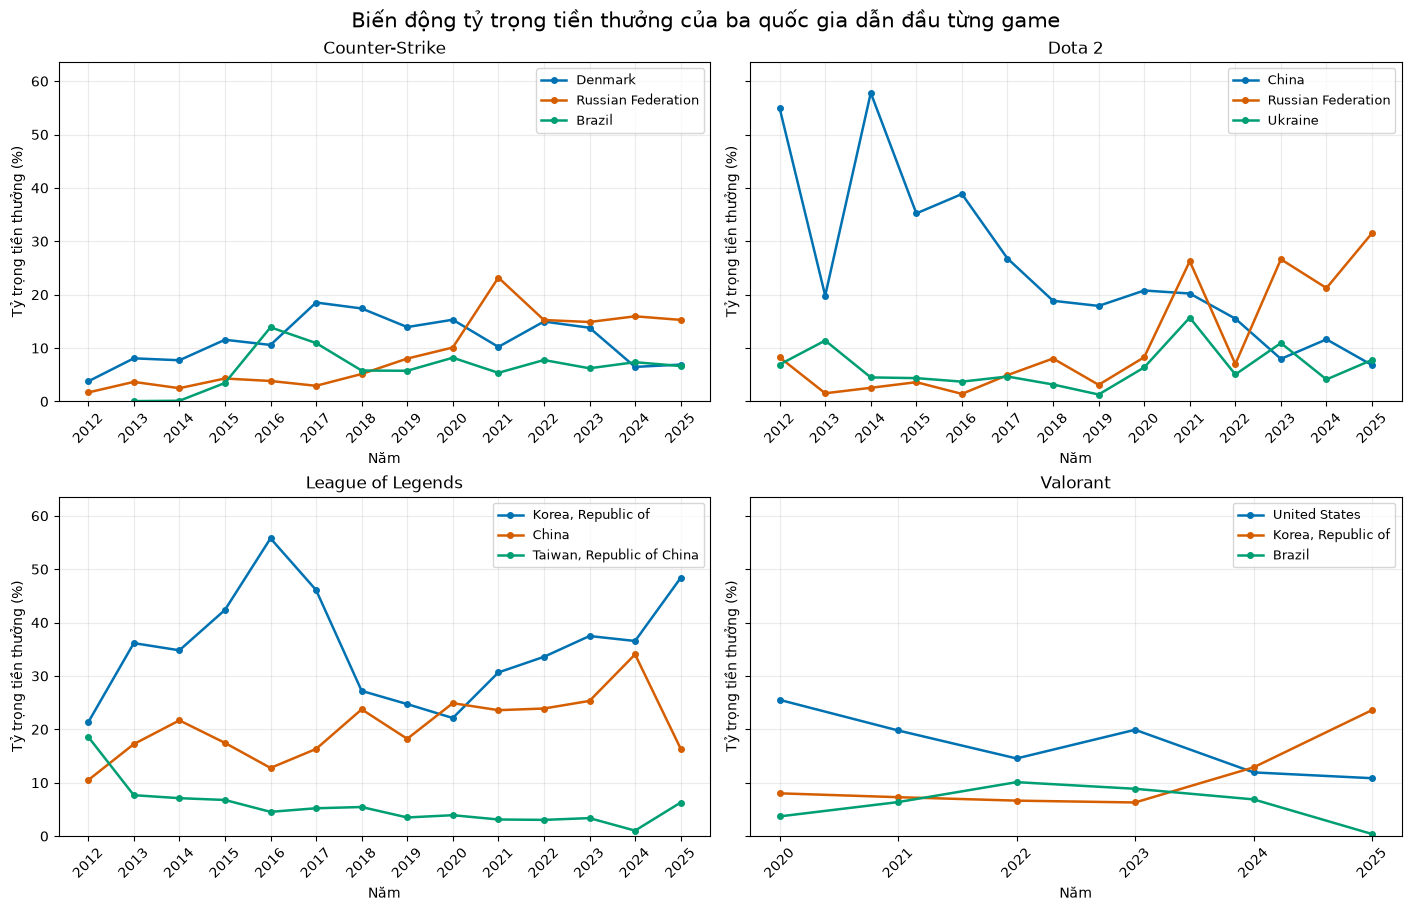

In [12]:
games = [
    "Counter-Strike",
    "Dota 2",
    "League of Legends",
    "Valorant",
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9),
    sharey=True,
    layout="constrained"
)

colors = ["#0072B2", "#D55E00", "#009E73"]

for ax, game in zip(axes.flat, games):
    game_data = country_year.loc[
        country_year["game_family"].eq(game)
    ]

    game_leaders = leaders.loc[
        leaders["game_family"].eq(game)
    ]

    # Các năm có dữ liệu quốc gia của game
    years = sorted(game_data["year"].unique())

    for color, (_, leader) in zip(
        colors, game_leaders.iterrows()
    ):
        series = (
            game_data.loc[
                game_data["country_code"].eq(
                    leader["country_code"]
                )
            ]
            .set_index("year")["share_pct"]
            .reindex(years)
        )

        # Không tự thay dữ liệu thiếu bằng 0
        ax.plot(
            series.index,
            series.values,
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=color,
            label=leader["country_name"],
        )

    ax.set_title(game)
    ax.set_xlabel("Năm")
    ax.set_ylabel("Tỷ trọng tiền thưởng (%)")
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

# Giới hạn chung dựa trên toàn bộ các đường được vẽ
selected = country_year.merge(
    leaders[["game_family", "country_code"]],
    on=["game_family", "country_code"],
    how="inner",
    validate="many_to_one",
)

y_max = selected["share_pct"].max()

# sharey=True nên đặt một lần sẽ áp dụng cho cả bốn biểu đồ
axes.flat[0].set_ylim(
    0,
    min(100, y_max * 1.10)
)

fig.suptitle(
    "Biến động tỷ trọng tiền thưởng của ba quốc gia "
    "dẫn đầu từng game",
    fontsize=15
)

plt.show()